# Setup  

In [ ]:
!apt-get install r-base

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
r-base is already the newest version (4.5.3-1.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
!pip install "rpy2[all]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 10.9 MB/s eta 0:00:00


In [ ]:
import rpy2
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

In [ ]:
%load_ext rpy2.ipython

In [ ]:
import rpy2.robjects.packages as rpackages
from rpy2.robjects.vectors import StrVector

utils = rpackages.importr("utils")
utils.chooseCRANmirror(ind=1)

packages = ["lcmm"]
# packages = ["lcmm", "moments"]
utils.install_packages(StrVector(packages))

(as ‘lib’ is unspecified)












	‘/tmp/RtmpEip749/downloaded_packages’



<rpy2.rinterface_lib.sexp.NULLType object at 0x7aa1f038cb90> [0]

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:
drive.mount('/content/drive')

df_curated = pd.read_excel("/content/drive/MyDrive/data/PPMI_Curated_Data_Cut_Public_20260223.xlsx")

df_vital = pd.read_csv("/content/drive/MyDrive/data/Vital_Signs_21Mar2026.csv")

Mounted at /content/drive


# Inclusion criteria  


In [ ]:
curated = df_curated[[
    # ID
    "PATNO",
    "COHORT",
    "EVENT_ID",

    # time variable
    "YEAR", # visit year, derived from EVENT_ID, numeric
    "visit_date", # Month and Year of Clinical Visit (Note: Collection dates of DATSCAN, lumbar puncture, or other imaging/lab data may be different.)

    # sleep
    "rem", # REM Sleep Behavior Disorder Screening Questionnaire (RBDSQ) total score
    # autonomic dysfunction
    "scopa", # SCOPA-AUT Total Score
    # psychiatric
    "stai", #State-Trait Anxiety Index (STAI) Total Score
    # cognitive
    "DVT_SDM", # Symbol Digit Modalities Test t-score (age- and education-corrected), DVT_SDM = 10*SD + 50, where SD is derived as above
    # motor
    "updrs3_score", # Score is based on values taken when participant is either "OFF" PD medication or untreated for PD

    # demo & clinical
    "SEX",
    "EDUCYRS", #Years of Education capped at 20
    "age", # age at enrollment
    "fampd_bin",  # Family History of PD - Binary, 1 Any Family w/PD, 2 No Family w/PD
    "LEDD", # Total Levodopa Equivalent Daily Dose
    "duration_yrs", # Duration from PD Diagnosis to Enrollment (Years)
    "hy", # Reclassified Hoehn & Yahr Stage (includes OFF and untreated scores)
    "ageonset",
    "subgroup",
    "moca",
    "gds",
    "stai_state",
    "stai_trait",
    "pigd",
    "COG_COMPOSITE_INT",
    "COG_COMPOSITE_EXT",
    "td_pigd",
    "ess",
    "MSEADLG",
    "upsit_pctl15",
    "cogstate"
]].copy()

In [ ]:
vs = df_vital[[
    "PATNO",
    "EVENT_ID",
    "SYSSUP",   # Supine BP - systolic (mmHg)
    "SYSSTND"    # Standing BP - systolic (mmHg)
]].copy()

In [ ]:
df = curated.merge(
    vs,
    on=["PATNO", "EVENT_ID"],
    how="left",
    validate="one_to_one"
)

In [ ]:
df["delta_sbp"] = df["SYSSUP"] - df["SYSSTND"]
df["delta_sbp"].describe()

,delta_sbp
count,17203.000000
mean,4.076731
std,13.370832
min,-77.000000
25%,-4.000000
50%,3.000000
75%,11.000000
max,111.000000


(-50.0, 100.0)

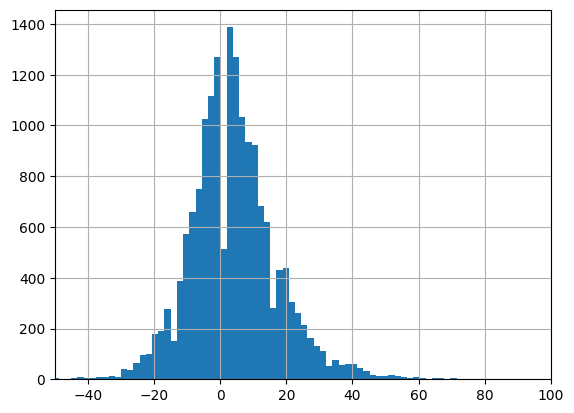

In [ ]:
df["delta_sbp"].hist(bins=100)
plt.xlim(-50, 100)

In [ ]:
df_pd = df[df["COHORT"] == 1].copy()

In [ ]:
bl_pd = df_pd[df_pd["YEAR"] == 0].copy()

In [ ]:
# boolean series
mask = (
    (bl_pd["ageonset"] >= 50) &
    (bl_pd["duration_yrs"] <=2) &
    (bl_pd["LEDD"] == 0) &
    (bl_pd["hy"] != 3) &
    (bl_pd["cogstate"] != 3)
)

ids = bl_pd.loc[mask, "PATNO"].dropna().unique()
print(len(ids))

919


In [ ]:
df_pd = df_pd[df_pd["PATNO"].isin(ids)].copy()

In [ ]:
visit_counts = df_pd.groupby("PATNO")["YEAR"].nunique()
ids_2plus = visit_counts[visit_counts >=2].index
df_pd_final = df_pd[df_pd["PATNO"].isin(ids_2plus)].copy()

In [ ]:
print(f"Unique subjects: {df_pd_final['PATNO'].nunique()}")
print(f"Total rows: {len(df_pd_final)}")

print("YEAR range:", df_pd_final["YEAR"].min(), df_pd_final["YEAR"].max())

print(df_pd_final.groupby("PATNO")["YEAR"].nunique().describe())

print(df_pd_final.groupby("YEAR")["PATNO"].nunique())

Unique subjects: 855
Total rows: 4542
YEAR range: 0 15
count    855.000000
mean       5.312281
std        3.653560
min        2.000000
25%        3.000000
50%        4.000000
75%        7.000000
max       15.000000
Name: YEAR, dtype: float64
YEAR
0     855
1     828
2     671
3     481
4     330
5     244
6     209
7     184
8     130
9     122
10    136
11    128
12    120
13     79
14     23
15      2
Name: PATNO, dtype: int64


In [ ]:
df_pd_final = df_pd_final[df_pd_final["YEAR"] <= 5].copy()

In [ ]:
print(f"Unique subjects: {df_pd_final['PATNO'].nunique()}")
print(f"Total rows: {len(df_pd_final)}")

print("YEAR range:", df_pd_final["YEAR"].min(), df_pd_final["YEAR"].max())

print(df_pd_final.groupby("PATNO")["YEAR"].nunique().describe())

print(df_pd_final.groupby("YEAR")["PATNO"].nunique())

Unique subjects: 855
Total rows: 3409
YEAR range: 0 5
count    855.000000
mean       3.987135
std        1.491921
min        2.000000
25%        3.000000
50%        4.000000
75%        6.000000
max        6.000000
Name: YEAR, dtype: float64
YEAR
0    855
1    828
2    671
3    481
4    330
5    244
Name: PATNO, dtype: int64


In [ ]:
vars_model = [
    "rem", "moca", "updrs3_score", "delta_sbp", "gds", "pigd"]

missing_model = df_pd_final[vars_model].isna().mean().sort_values(ascending=False)

print(missing_model)

updrs3_score    0.159871
pigd            0.157524
delta_sbp       0.029921
moca            0.010854
rem             0.008800
gds             0.008800
dtype: float64


In [ ]:
vars_model = ["rem", "moca", "updrs3_score", "delta_sbp", "gds", "pigd"]

vars_model = [c for c in vars_model if c in df_pd_final.columns]

scale_yr_sub_df = (
    df_pd_final[["PATNO", "YEAR"] + vars_model]
    .dropna(subset=vars_model, how="all")
    .groupby("YEAR")[["PATNO"] + vars_model]
    .apply(lambda x: x.groupby("PATNO")[vars_model].apply(lambda y: y.notna().any()).sum())
)

display(scale_yr_sub_df)

,rem,moca,updrs3_score,delta_sbp,gds,pigd
YEAR,,,,,,
0,851,853,850,849,852,852
1,821,821,698,792,822,701
2,666,664,529,643,664,532
3,477,474,354,465,478,355
4,323,320,250,317,321,249
5,241,240,183,241,242,183


In [ ]:
# activate conversion between pandas df and r df
pandas2ri.activate()

ro.globalenv["df"] = df_pd_final

# lcmm_rem random=~1

## linear

In [ ]:
ro.r(r"""
library(lcmm)

m1_rem_intercept_linear <- lcmm(
  fixed = rem ~ YEAR,
  random = ~ 1,
  subject = "PATNO",
  data = df,
  ng = 1
)

summary(m1_rem_intercept_linear)
""")


General latent class mixed model 
     fitted by maximum likelihood method 
 
lcmm(fixed = rem ~ YEAR, random = ~1, subject = "PATNO", ng = 1, 
    data = df)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 855 
     Number of observations: 3379 
     Number of observations deleted: 30 
     Number of latent classes: 1 
     Number of parameters: 4  
     Link function: linear  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  6 
     Convergence criteria: parameters= 1.1e-07 
                         : likelihood= 5e-05 
                         : second derivatives= 1.1e-12 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -7504.38  
     AIC: 15016.75  
     BIC: 15035.76  
 
     Discrete posterior log-likelihood: -7434.85  
     Discrete AIC: 14877.7  
 
     Mean discrete AIC per subject: 8.7004  
     Mean UACV per subject: 8.7025  
     Mean discrete LL per subject: -8.6957  
 
Maximum Likelihood Estimates: 
 
Fi

In [ ]:
ro.r(r"""
library(lcmm)

m2_rem_intercept_linear <- lcmm(
  fixed = rem ~ YEAR,
  random = ~ 1,
  mixture = ~ YEAR,
  subject = "PATNO",
  data = df,
  ng = 2,
  B = m1_rem_intercept_linear
)

summary(m2_rem_intercept_linear)
""")


General latent class mixed model 
     fitted by maximum likelihood method 
 
lcmm(fixed = rem ~ YEAR, mixture = ~YEAR, random = ~1, subject = "PATNO", 
    ng = 2, data = df)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 855 
     Number of observations: 3379 
     Number of observations deleted: 30 
     Number of latent classes: 2 
     Number of parameters: 7  
     Link function: linear  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  15 
     Convergence criteria: parameters= 2.6e-07 
                         : likelihood= 1.1e-05 
                         : second derivatives= 5.2e-13 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -7403.28  
     AIC: 14820.56  
     BIC: 14853.82  
 
     Discrete posterior log-likelihood: -7342.46  
     Discrete AIC: 14698.92  
 
     Mean discrete AIC per subject: 8.5959  
     Mean UACV per subject: 8.6007  
     Mean discrete LL per subject: -8.5877  
 
Maximum Likeli

In [ ]:
ro.r(r"""
library(lcmm)

m3_rem_intercept_linear <- lcmm(
  fixed = rem ~ YEAR,
  random = ~ 1,
  mixture = ~ YEAR,
  subject = "PATNO",
  data = df,
  ng = 3,
  B = m1_rem_intercept_linear
)

summary(m3_rem_intercept_linear)
""")


General latent class mixed model 
     fitted by maximum likelihood method 
 
lcmm(fixed = rem ~ YEAR, mixture = ~YEAR, random = ~1, subject = "PATNO", 
    ng = 3, data = df)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 855 
     Number of observations: 3379 
     Number of observations deleted: 30 
     Number of latent classes: 3 
     Number of parameters: 10  
     Link function: linear  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  23 
     Convergence criteria: parameters= 1.2e-06 
                         : likelihood= 2.9e-05 
                         : second derivatives= 1.4e-09 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -7326.08  
     AIC: 14672.16  
     BIC: 14719.67  
 
     Discrete posterior log-likelihood: -7271.71  
     Discrete AIC: 14563.42  
 
     Mean discrete AIC per subject: 8.5166  
     Mean UACV per subject: 8.52  
     Mean discrete LL per subject: -8.5049  
 
Maximum Likelih

In [ ]:
ro.r(r"""
library(lcmm)

m4_rem_intercept_linear <- lcmm(
  fixed = rem ~ YEAR,
  random = ~ 1,
  mixture = ~ YEAR,
  subject = "PATNO",
  data = df,
  ng = 4,
  B = m1_rem_intercept_linear
)

summary(m4_rem_intercept_linear)
""")


General latent class mixed model 
     fitted by maximum likelihood method 
 
lcmm(fixed = rem ~ YEAR, mixture = ~YEAR, random = ~1, subject = "PATNO", 
    ng = 4, data = df)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 855 
     Number of observations: 3379 
     Number of observations deleted: 30 
     Number of latent classes: 4 
     Number of parameters: 13  
     Link function: linear  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  34 
     Convergence criteria: parameters= 5.9e-12 
                         : likelihood= 1.8e-10 
                         : second derivatives= 4e-11 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -7326.08  
     AIC: 14678.16  
     BIC: 14739.92  
 
     Discrete posterior log-likelihood: -7271.71  
     Discrete AIC: 14569.42  
 
     Mean discrete AIC per subject: 8.5201  
     Mean UACV per subject: 8.5201  
     Mean discrete LL per subject: -8.5049  
 
Maximum Likelih

In [ ]:
ro.r(r"""
library(lcmm)

m5_rem_intercept_linear <- lcmm(
  fixed = rem ~ YEAR,
  random = ~ 1,
  mixture = ~ YEAR,
  subject = "PATNO",
  data = df,
  ng = 5,
  B = m1_rem_intercept_linear
)

summary(m5_rem_intercept_linear)
""")


General latent class mixed model 
     fitted by maximum likelihood method 
 
lcmm(fixed = rem ~ YEAR, mixture = ~YEAR, random = ~1, subject = "PATNO", 
    ng = 5, data = df)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 855 
     Number of observations: 3379 
     Number of observations deleted: 30 
     Number of latent classes: 5 
     Number of parameters: 16  
     Link function: linear  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  34 
     Convergence criteria: parameters= 3.5e-11 
                         : likelihood= 2.4e-10 
                         : second derivatives= 2.3e-12 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -7326.08  
     AIC: 14684.16  
     BIC: 14760.18  
 
     Discrete posterior log-likelihood: -7271.71  
     Discrete AIC: 14575.42  
 
     Mean discrete AIC per subject: 8.5236  
     Mean UACV per subject: 8.5201  
     Mean discrete LL per subject: -8.5049  
 
Maximum Likel

In [ ]:
ro.r("""
  summarytable(m1_rem_intercept_linear, m2_rem_intercept_linear, m3_rem_intercept_linear, m4_rem_intercept_linear, m5_rem_intercept_linear,
               which = c("G", "loglik", "entropy", "AIC", "BIC", "%class"))
""")

                        G    loglik   entropy      AIC      BIC   %class1
m1_rem_intercept_linear 1 -7504.377 1.0000000 15016.75 15035.76 100.00000
m2_rem_intercept_linear 2 -7403.282 0.7973444 14820.56 14853.82  27.36842
m3_rem_intercept_linear 3 -7326.080 0.7573811 14672.16 14719.67  19.29825
m4_rem_intercept_linear 4 -7326.080 0.5375571 14678.16 14739.92  15.32164
m5_rem_intercept_linear 5 -7326.080 0.4165107 14684.16 14760.18  17.89474
                         %class2  %class3  %class4 %class5
m1_rem_intercept_linear                                   
m2_rem_intercept_linear 72.63158                          
m3_rem_intercept_linear 66.43275 14.26901                 
m4_rem_intercept_linear 19.41520 65.26316  0.00000        
m5_rem_intercept_linear 19.41520  0.00000 62.69006       0


In [ ]:
%%R

library(lcmm)

models <- list(
  m1_rem_intercept_linear = m1_rem_intercept_linear,
  m2_rem_intercept_linear = m2_rem_intercept_linear,
  m3_rem_intercept_linear = m3_rem_intercept_linear,
  m4_rem_intercept_linear = m4_rem_intercept_linear,
  m5_rem_intercept_linear = m5_rem_intercept_linear
)

for (nm in names(models)) {
  cat("\n=============================\n")
  cat("Model:", nm, "\n")
  cat("=============================\n")

  pp <- postprob(models[[nm]])

  print(pp)
}


Model: m1_rem_intercept_linear 
Postprob function can only be used when ng > 1 
list()

Model: m2_rem_intercept_linear 
 
Posterior classification: 
  class1 class2
N 234.00 621.00
%  27.37  72.63
 
Posterior classification table: 
     --> mean of posterior probabilities in each class 
        prob1  prob2
class1 0.9015 0.0985
class2 0.0423 0.9577
 
Posterior probabilities above a threshold (%): 
         class1 class2
prob>0.7  89.32  95.17
prob>0.8  78.63  91.79
prob>0.9  68.80  87.44
 
[[1]]
  class1 class2
N 234.00 621.00
%  27.37  72.63

[[2]]
        prob1  prob2
class1 0.9015 0.0985
class2 0.0423 0.9577

[[3]]
         class1 class2
prob>0.7  89.32  95.17
prob>0.8  78.63  91.79
prob>0.9  68.80  87.44


Model: m3_rem_intercept_linear 
 
Posterior classification: 
  class1 class2 class3
N  165.0 568.00 122.00
%   19.3  66.43  14.27
 
Posterior classification table: 
     --> mean of posterior probabilities in each class 
        prob1  prob2  prob3
class1 0.8697 0.0416 0.0887
cl

In [ ]:
%%R

pp <- as.data.frame(m3_rem_intercept_linear$pprob)

vc <- as.data.frame(table(df$PATNO))
names(vc) <- c("PATNO", "Visit_Count")
# vc$PATNO <- as.numeric(as.character(vc$PATNO))

pp <- merge(pp, vc, by = "PATNO", all.x = TRUE)

prob_cols <- grep("^prob", names(pp), value = TRUE)
pp$max_prob <- apply(pp[, prob_cols, drop = FALSE], 1, max, na.rm = TRUE)

write.csv(
  pp,
  "/content/drive/MyDrive/data/random/rem_intercept_linear_m3_postprob.csv",
  row.names = FALSE
)

In [ ]:
%%R

saveRDS(m3_rem_intercept_linear, "/content/drive/MyDrive/data/random/rem_intercept_linear_m3.rds")

Rows: 855 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (7): PATNO, class, prob1, prob2, prob3, Visit_Count, max_prob

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


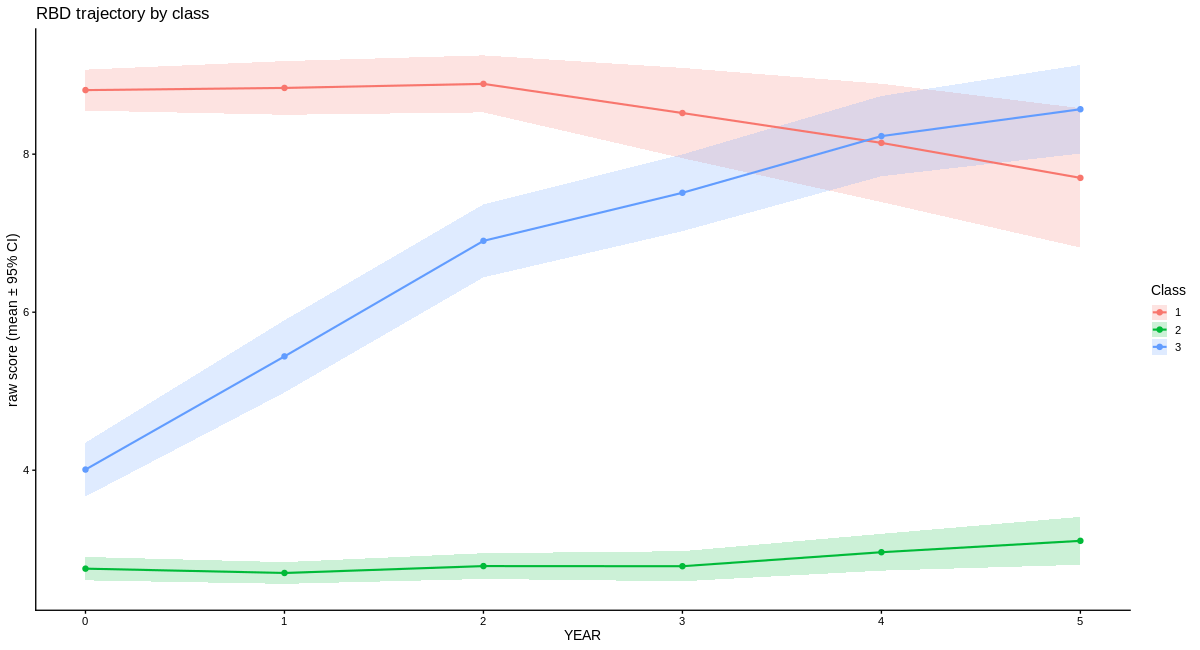

In [ ]:
%%R -w 1200 -h 650

library(ggplot2)
library(dplyr)
library(readr)

pp <- read_csv("/content/drive/MyDrive/data/random/rem_intercept_linear_m3_postprob.csv")

pp$class <- factor(pp$class)

pp$PATNO <- as.numeric(pp$PATNO)
df$PATNO <- as.numeric(df$PATNO)

plot_var   <- "rem"
plot_label <- "RBD"

d <- df %>%
  select(PATNO, YEAR, all_of(plot_var)) %>%
  left_join(pp %>% select(PATNO, class), by = "PATNO") %>%
  filter(!is.na(class))

plot_df <- d %>%
  group_by(class, YEAR) %>%
  summarise(
    mean = mean(.data[[plot_var]], na.rm = TRUE),
    sd   = sd(.data[[plot_var]], na.rm = TRUE),
    n    = sum(!is.na(.data[[plot_var]])),
    se   = sd / sqrt(n),
    ci_low  = mean - 1.96 * se,
    ci_high = mean + 1.96 * se,
    .groups = "drop"
  )

ggplot(plot_df, aes(x = YEAR, y = mean, color = class, group = class, fill = class)) +
  geom_ribbon(aes(ymin = ci_low, ymax = ci_high), alpha = 0.20, colour = NA) +
  geom_line(linewidth = 1) +
  geom_point(size = 2.2) +
  labs(
    title = paste0(plot_label, " trajectory by class"),
    x = "YEAR",
    y = "raw score (mean ± 95% CI)",
    color = "Class",
    fill  = "Class"
  ) +
  theme_classic(base_size = 14)

## linear OCC

In [ ]:
%%R

library(readr)
library(dplyr)
library(stringr)
library(purrr)

pp <- read_csv("/content/drive/MyDrive/data/random/rem_intercept_linear_m3_postprob.csv")

prob_cols <- names(pp) %>% str_subset("^prob[0-9]+$")

pp <- pp %>%
  mutate(class = as.integer(class))

N <- nrow(pp)

class_metrics <- map_dfr(seq_along(prob_cols), function(k) {

  prob_k <- prob_cols[k]

  idx <- pp$class == k
  n_k <- sum(idx, na.rm = TRUE)

  pbar_k <- mean(pp[[prob_k]][idx], na.rm = TRUE)
  pi_k   <- n_k / N # hard class proportion

  occ_k <- (pbar_k / (1 - pbar_k)) / (pi_k / (1 - pi_k))

  tibble(
    class = k,
    n = n_k,
    class_prop = pi_k,
    APPA = pbar_k,
    OCC = occ_k
  )
})

class_metrics

Rows: 855 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (7): PATNO, class, prob1, prob2, prob3, Visit_Count, max_prob

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
# A tibble: 3 × 5
  class     n class_prop  APPA   OCC
  <int> <int>      <dbl> <dbl> <dbl>
1     1   165      0.193 0.870 27.9 
2     2   568      0.664 0.924  6.11
3     3   122      0.143 0.794 23.1 


# multlcmm, random=~1, raw score+moca_transform, linear

## model  

trans_moca reference:  
A predictive model for longitudinal cognitive subtypes in Parkinson's disease  
https://doi.org/10.1007/s10072-024-07953-3


In [ ]:
df_pd_final["trans_moca"] = np.sqrt(31 - df_pd_final["moca"])

In [ ]:
df_pd_final["trans_moca"].describe()

,trans_moca
count,3372.000000
mean,2.023156
std,0.670139
min,1.000000
25%,1.414214
50%,2.000000
75%,2.449490
max,5.385165


In [ ]:
# activate conversion between pandas df and r df
pandas2ri.activate()

ro.globalenv["df"] = df_pd_final

In [ ]:
ro.r("""
library(lcmm)

m1_rmus_intercept_raw_trans_linear <- multlcmm(
  fixed   = rem + trans_moca + updrs3_score + delta_sbp ~ YEAR,
  random  = ~ 1,
  subject = "PATNO",
  ng      = 1,
  data    = df
)

summary(m1_rmus_intercept_raw_trans_linear)

""")

General latent class mixed model 
     fitted by maximum likelihood method 
 
multlcmm(fixed = rem + trans_moca + updrs3_score + delta_sbp ~ 
    YEAR, random = ~1, subject = "PATNO", ng = 1, data = df)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 855 
     Number of observations: 12922 
     Number of latent classes: 1 
     Number of parameters: 13  
     Link functions: Linear for rem  
                     Linear for trans_moca  
                     Linear for updrs3_score  
                     Linear for delta_sbp  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  21 
     Convergence criteria: parameters= 5.6e-06 
                         : likelihood= 1.2e-06 
                         : second derivatives= 1.1e-09 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -35284.04  
     AIC: 70594.07  
     BIC: 70655.84  
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

                 

In [ ]:
ro.r("""
library(lcmm)

m2_rmus_intercept_raw_trans_linear <- multlcmm(
  fixed   = rem + trans_moca + updrs3_score + delta_sbp ~ YEAR,
  random  = ~ 1,
  mixture  = ~ YEAR,
  subject = "PATNO",
  ng      = 2,
  data    = df,
  B = m1_rmus_intercept_raw_trans_linear
)

summary(m2_rmus_intercept_raw_trans_linear)

""")

General latent class mixed model 
     fitted by maximum likelihood method 
 
multlcmm(fixed = rem + trans_moca + updrs3_score + delta_sbp ~ 
    YEAR, mixture = ~YEAR, random = ~1, subject = "PATNO", ng = 2, 
    data = df)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 855 
     Number of observations: 12922 
     Number of latent classes: 2 
     Number of parameters: 16  
     Link functions: Linear for rem  
                     Linear for trans_moca  
                     Linear for updrs3_score  
                     Linear for delta_sbp  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  30 
     Convergence criteria: parameters= 4.7e-05 
                         : likelihood= 4.5e-06 
                         : second derivatives= 1.9e-09 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -35180.5  
     AIC: 70392.99  
     BIC: 70469.01  
 
Maximum Likelihood Estimates: 
 
Fixed effects in the class-membership 

In [ ]:
ro.r("""
library(lcmm)

m3_rmus_intercept_raw_trans_linear <- multlcmm(
  fixed   = rem + trans_moca + updrs3_score + delta_sbp ~ YEAR,
  random  = ~ 1,
  mixture  = ~ YEAR,
  subject = "PATNO",
  ng      = 3,
  data    = df,
  B = m1_rmus_intercept_raw_trans_linear
)

summary(m3_rmus_intercept_raw_trans_linear)

""")

General latent class mixed model 
     fitted by maximum likelihood method 
 
multlcmm(fixed = rem + trans_moca + updrs3_score + delta_sbp ~ 
    YEAR, mixture = ~YEAR, random = ~1, subject = "PATNO", ng = 3, 
    data = df)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 855 
     Number of observations: 12922 
     Number of latent classes: 3 
     Number of parameters: 19  
     Link functions: Linear for rem  
                     Linear for trans_moca  
                     Linear for updrs3_score  
                     Linear for delta_sbp  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  41 
     Convergence criteria: parameters= 8.2e-07 
                         : likelihood= 1.7e-08 
                         : second derivatives= 2.5e-11 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -35110.15  
     AIC: 70258.3  
     BIC: 70348.57  
 
Maximum Likelihood Estimates: 
 
Fixed effects in the class-membership 

In [ ]:
ro.r("""
library(lcmm)

m4_rmus_intercept_raw_trans_linear <- multlcmm(
  fixed   = rem + trans_moca + updrs3_score + delta_sbp ~ YEAR,
  random  = ~ 1,
  mixture  = ~ YEAR,
  subject = "PATNO",
  ng      = 4,
  data    = df,
  B = m1_rmus_intercept_raw_trans_linear
)

summary(m4_rmus_intercept_raw_trans_linear)

""")

General latent class mixed model 
     fitted by maximum likelihood method 
 
multlcmm(fixed = rem + trans_moca + updrs3_score + delta_sbp ~ 
    YEAR, mixture = ~YEAR, random = ~1, subject = "PATNO", ng = 4, 
    data = df)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 855 
     Number of observations: 12922 
     Number of latent classes: 4 
     Number of parameters: 22  
     Link functions: Linear for rem  
                     Linear for trans_moca  
                     Linear for updrs3_score  
                     Linear for delta_sbp  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  43 
     Convergence criteria: parameters= 1.7e-09 
                         : likelihood= 2.6e-10 
                         : second derivatives= 9.2e-11 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -35110.15  
     AIC: 70264.3  
     BIC: 70368.82  
 
Maximum Likelihood Estimates: 
 
Fixed effects in the class-membership 

In [ ]:
ro.r("""
  summarytable(m1_rmus_intercept_raw_trans_linear, m2_rmus_intercept_raw_trans_linear, m3_rmus_intercept_raw_trans_linear, m4_rmus_intercept_raw_trans_linear,
               which = c("G", "loglik", "entropy", "AIC", "BIC", "%class"))
""")

                                   G    loglik   entropy      AIC      BIC
m1_rmus_intercept_raw_trans_linear 1 -35284.04 1.0000000 70594.07 70655.84
m2_rmus_intercept_raw_trans_linear 2 -35180.50 0.7946713 70392.99 70469.01
m3_rmus_intercept_raw_trans_linear 3 -35110.15 0.7527719 70258.30 70348.57
m4_rmus_intercept_raw_trans_linear 4 -35110.15 0.4963126 70264.30 70368.82
                                     %class1  %class2  %class3 %class4
m1_rmus_intercept_raw_trans_linear 100.00000                          
m2_rmus_intercept_raw_trans_linear  28.77193 71.22807                 
m3_rmus_intercept_raw_trans_linear  20.23392 66.43275 13.33333        
m4_rmus_intercept_raw_trans_linear  15.08772 20.46784 64.44444       0


In [ ]:
%%R

library(lcmm)

models <- list(
  m1_rmus_intercept_raw_trans_linear = m1_rmus_intercept_raw_trans_linear,
  m2_rmus_intercept_raw_trans_linear = m2_rmus_intercept_raw_trans_linear,
  m3_rmus_intercept_raw_trans_linear = m3_rmus_intercept_raw_trans_linear,
  m4_rmus_intercept_raw_trans_linear = m4_rmus_intercept_raw_trans_linear
)

for (nm in names(models)) {
  cat("\n=============================\n")
  cat("Model:", nm, "\n")
  cat("=============================\n")

  pp <- postprob(models[[nm]])

  print(pp)
}


Model: m1_rmus_intercept_raw_trans_linear 
Postprob function can only be used when ng > 1 
list()

Model: m2_rmus_intercept_raw_trans_linear 
 
Posterior classification: 
  class1 class2
N 246.00 609.00
%  28.77  71.23
 
Posterior classification table: 
     --> mean of posterior probabilities in each class 
        prob1  prob2
class1 0.8942 0.1058
class2 0.0394 0.9606
 
Posterior probaBIlities above a threshold (%): 
         class1 class2
prob>0.7  85.37  96.55
prob>0.8  77.24  93.43
prob>0.9  66.67  87.85
 
[[1]]
  class1 class2
N 246.00 609.00
%  28.77  71.23

[[2]]
        prob1  prob2
class1 0.8942 0.1058
class2 0.0394 0.9606

[[3]]
         class1 class2
prob>0.7  85.37  96.55
prob>0.8  77.24  93.43
prob>0.9  66.67  87.85


Model: m3_rmus_intercept_raw_trans_linear 
 
Posterior classification: 
  class1 class2 class3
N 173.00 568.00 114.00
%  20.23  66.43  13.33
 
Posterior classification table: 
     --> mean of posterior probabilities in each class 
        prob1  prob2  pro

In [ ]:
%%R

pp <- as.data.frame(m3_rmus_intercept_raw_trans_linear$pprob)

vc <- as.data.frame(table(df$PATNO))
names(vc) <- c("PATNO", "Visit_Count")
vc$PATNO <- as.numeric(as.character(vc$PATNO))

pp <- merge(pp, vc, by = "PATNO", all.x = TRUE)

prob_cols <- grep("^prob", names(pp), value = TRUE)
pp$max_prob <- apply(pp[, prob_cols, drop = FALSE], 1, max, na.rm = TRUE)

write.csv(
  pp,
  "/content/drive/MyDrive/data/random/m3_rmus_intercept_raw_trans_linear_postprob.csv",
  row.names = FALSE
)

In [ ]:
%%R

saveRDS(m3_rmus_intercept_raw_trans_linear, "/content/drive/MyDrive/data/random/m3_rmus_intercept_raw_trans_linear.rds")

Rows: 855 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (7): PATNO, class, prob1, prob2, prob3, Visit_Count, max_prob

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


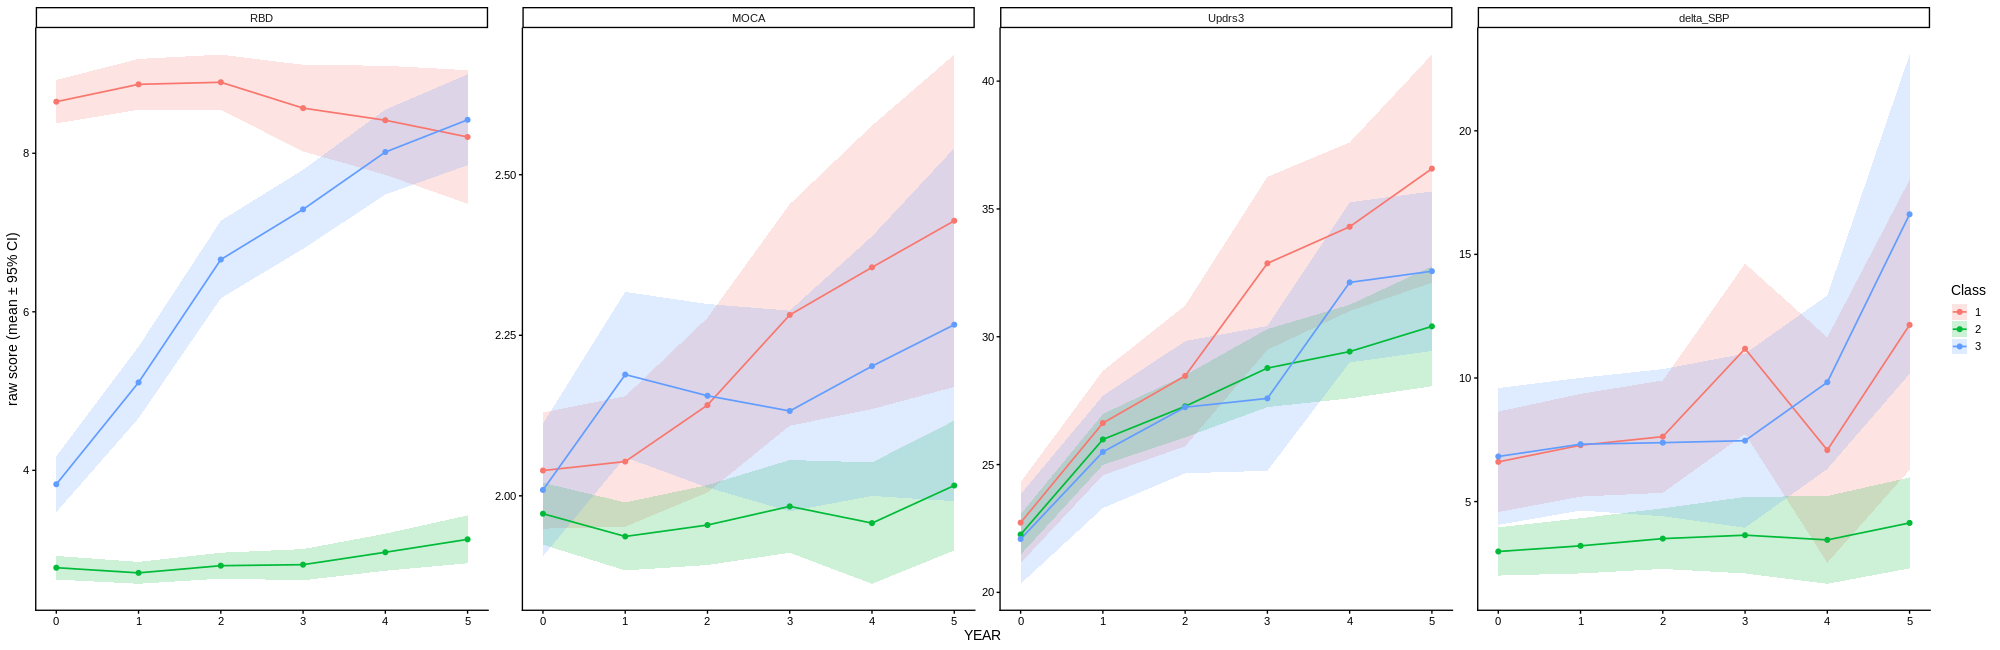

In [ ]:
%%R -w 2000 -h 650

library(ggplot2)
library(dplyr)
library(tidyr)
library(readr)

pp <- read_csv("/content/drive/MyDrive/data/random/m3_rmus_intercept_raw_trans_linear_postprob.csv")

pp$class <- factor(pp$class)

pp$PATNO <- as.numeric(pp$PATNO)
df$PATNO <- as.numeric(df$PATNO)

d <- df %>%
  select(PATNO, YEAR, rem, trans_moca, updrs3_score, delta_sbp) %>%
  left_join(pp %>% select(PATNO, class), by = "PATNO")

table(is.na(d$class))

long <- d %>%
  pivot_longer(
    cols = c(rem, trans_moca, updrs3_score, delta_sbp),
    names_to = "domain",
    values_to = "value"
  ) %>%
  mutate(
    domain = recode(
      domain,
      rem = "RBD",
      trans_moca = "MOCA",
      updrs3_score = "Updrs3",
      delta_sbp = "delta_SBP"
    ),
    domain = factor(domain, levels = c("RBD", "MOCA", "Updrs3", "delta_SBP"))
  )

plot_df <- long %>%
  group_by(class, YEAR, domain) %>%
  summarise(
    mean = mean(value, na.rm = TRUE),
    sd   = sd(value, na.rm = TRUE),
    n    = sum(!is.na(value)),
    se   = sd / sqrt(n),
    ci_low  = mean - 1.96 * se,
    ci_high = mean + 1.96 * se,
    .groups = "drop"
  )

ggplot(plot_df, aes(x = YEAR, y = mean, color = class, group = class, fill = class)) +
  geom_ribbon(aes(ymin = ci_low, ymax = ci_high), alpha = 0.20, colour = NA) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2) +
  facet_wrap(~domain, nrow = 1, scales = "free_y") +
  labs(
    x = "YEAR",
    y = "raw score (mean ± 95% CI)",
    color = "Class",
    fill  = "Class"
  ) + theme_classic(base_size = 14)

## OCC

In [ ]:
%%R

library(readr)
library(dplyr)
library(stringr)
library(purrr)

pp <- read_csv("/content/drive/MyDrive/data/random/m3_rmus_intercept_raw_trans_linear_postprob.csv")

prob_cols <- names(pp) %>% str_subset("^prob[0-9]+$")

pp <- pp %>%
  mutate(class = as.integer(class))

N <- nrow(pp)

class_metrics <- map_dfr(seq_along(prob_cols), function(k) {

  prob_k <- prob_cols[k]

  idx <- pp$class == k
  n_k <- sum(idx, na.rm = TRUE)

  pbar_k <- mean(pp[[prob_k]][idx], na.rm = TRUE)
  pi_k   <- n_k / N # hard class proportion

  occ_k <- (pbar_k / (1 - pbar_k)) / (pi_k / (1 - pi_k))

  tibble(
    class = k,
    n = n_k,
    class_prop = pi_k,
    APPA = pbar_k,
    OCC = occ_k
  )
})

class_metrics

Rows: 855 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (7): PATNO, class, prob1, prob2, prob3, Visit_Count, max_prob

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
# A tibble: 3 × 5
  class     n class_prop  APPA   OCC
  <int> <int>      <dbl> <dbl> <dbl>
1     1   173      0.202 0.868 26.0 
2     2   568      0.664 0.922  5.98
3     3   114      0.133 0.787 24.0 


# multlcmm, random=~YEAR, raw score+moca_transform, linear (3-class did not converge)

## model

In [ ]:
df_pd_final["trans_moca"] = np.sqrt(31 - df_pd_final["moca"])

In [ ]:
df_pd_final["trans_moca"].describe()

,trans_moca
count,3372.000000
mean,2.023156
std,0.670139
min,1.000000
25%,1.414214
50%,2.000000
75%,2.449490
max,5.385165


In [ ]:
# activate conversion between pandas df and r df
pandas2ri.activate()

ro.globalenv["df"] = df_pd_final

In [ ]:
ro.r("""
library(lcmm)

m1_rmus_inter_slope_raw_trans_linear <- multlcmm(
  fixed   = rem + trans_moca + updrs3_score + delta_sbp ~ YEAR,
  random  = ~ YEAR,
  subject = "PATNO",
  ng      = 1,
  data    = df
)

summary(m1_rmus_inter_slope_raw_trans_linear)

""")

General latent class mixed model 
     fitted by maximum likelihood method 
 
multlcmm(fixed = rem + trans_moca + updrs3_score + delta_sbp ~ 
    YEAR, random = ~YEAR, subject = "PATNO", ng = 1, data = df)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 855 
     Number of observations: 12922 
     Number of latent classes: 1 
     Number of parameters: 15  
     Link functions: Linear for rem  
                     Linear for trans_moca  
                     Linear for updrs3_score  
                     Linear for delta_sbp  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  33 
     Convergence criteria: parameters= 3.4e-05 
                         : likelihood= 2.2e-05 
                         : second derivatives= 2.5e-09 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -35238.63  
     AIC: 70507.27  
     BIC: 70578.53  
 
Maximum Likelihood Estimates: 
 
Fixed effects in the longitudinal model:

              

In [ ]:
ro.r("""
library(lcmm)

m2_rmus_inter_slope_raw_trans_linear <- multlcmm(
  fixed   = rem + trans_moca + updrs3_score + delta_sbp ~ YEAR,
  random  = ~ YEAR,
  mixture  = ~ YEAR,
  subject = "PATNO",
  ng      = 2,
  data    = df,
  B = m1_rmus_inter_slope_raw_trans_linear
)

summary(m2_rmus_inter_slope_raw_trans_linear)

""")

General latent class mixed model 
     fitted by maximum likelihood method 
 
multlcmm(fixed = rem + trans_moca + updrs3_score + delta_sbp ~ 
    YEAR, mixture = ~YEAR, random = ~YEAR, subject = "PATNO", 
    ng = 2, data = df)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 855 
     Number of observations: 12922 
     Number of latent classes: 2 
     Number of parameters: 18  
     Link functions: Linear for rem  
                     Linear for trans_moca  
                     Linear for updrs3_score  
                     Linear for delta_sbp  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  72 
     Convergence criteria: parameters= 1.7e-06 
                         : likelihood= 2.4e-08 
                         : second derivatives= 5.6e-11 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -35139.62  
     AIC: 70315.23  
     BIC: 70400.75  
 
Maximum Likelihood Estimates: 
 
Fixed effects in the class-members

In [ ]:
ro.r("""
library(lcmm)

m3_rmus_inter_slope_raw_trans_linear <- multlcmm(
  fixed   = rem + trans_moca + updrs3_score + delta_sbp ~ YEAR,
  random  = ~ YEAR,
  mixture  = ~ YEAR,
  subject = "PATNO",
  ng      = 3,
  data    = df,
  B = m1_rmus_inter_slope_raw_trans_linear
)

summary(m3_rmus_inter_slope_raw_trans_linear)

""")

General latent class mixed model 
     fitted by maximum likelihood method 
 
multlcmm(fixed = rem + trans_moca + updrs3_score + delta_sbp ~ 
    YEAR, mixture = ~YEAR, random = ~YEAR, subject = "PATNO", 
    ng = 3, data = df)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 855 
     Number of observations: 12922 
     Number of latent classes: 3 
     Number of parameters: 21  
     Link functions: Linear for rem  
                     Linear for trans_moca  
                     Linear for updrs3_score  
                     Linear for delta_sbp  
 
Iteration process: 
     Maximum number of iteration reached without convergence 
     Number of iterations:  100 
     Convergence criteria: parameters= 1.7e-08 
                         : likelihood= 1.3e-06 
                         : second derivatives= 0.00014 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -35107.92  
     AIC: 70257.83  
     BIC: 70357.6  
 
Maximum Likelihood Estimates: 
 
Fixed eff

In [ ]:
ro.r("""
library(lcmm)

m4_rmus_inter_slope_raw_trans_linear <- multlcmm(
  fixed   = rem + trans_moca + updrs3_score + delta_sbp ~ YEAR,
  random  = ~ YEAR,
  mixture  = ~ YEAR,
  subject = "PATNO",
  ng      = 4,
  data    = df,
  B = m1_rmus_inter_slope_raw_trans_linear
)

summary(m4_rmus_inter_slope_raw_trans_linear)

""")

General latent class mixed model 
     fitted by maximum likelihood method 
 
multlcmm(fixed = rem + trans_moca + updrs3_score + delta_sbp ~ 
    YEAR, mixture = ~YEAR, random = ~YEAR, subject = "PATNO", 
    ng = 4, data = df)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 855 
     Number of observations: 12922 
     Number of latent classes: 4 
     Number of parameters: 24  
     Link functions: Linear for rem  
                     Linear for trans_moca  
                     Linear for updrs3_score  
                     Linear for delta_sbp  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  78 
     Convergence criteria: parameters= 1.3e-07 
                         : likelihood= 5.6e-06 
                         : second derivatives= 9e-05 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -35107.92  
     AIC: 70263.83  
     BIC: 70377.86  
 
Maximum Likelihood Estimates: 
 
Fixed effects in the class-membershi

In [ ]:
ro.r("""
  summarytable(m1_rmus_inter_slope_raw_trans_linear, m2_rmus_inter_slope_raw_trans_linear, m3_rmus_inter_slope_raw_trans_linear, m4_rmus_inter_slope_raw_trans_linear,
               which = c("G", "loglik", "entropy", "AIC", "BIC", "%class"))
""")

                                     G    loglik   entropy      AIC      BIC
m1_rmus_inter_slope_raw_trans_linear 1 -35238.63 1.0000000 70507.27 70578.53
m2_rmus_inter_slope_raw_trans_linear 2 -35139.62 0.8465820 70315.23 70400.75
m3_rmus_inter_slope_raw_trans_linear 3 -35107.92 0.7563903 70257.83 70357.60
m4_rmus_inter_slope_raw_trans_linear 4 -35107.92 0.4897604 70263.83 70377.86
                                       %class1  %class2  %class3 %class4
m1_rmus_inter_slope_raw_trans_linear 100.00000                          
m2_rmus_inter_slope_raw_trans_linear  21.75439 78.24561                 
m3_rmus_inter_slope_raw_trans_linear  13.33333 66.43275 20.23392        
m4_rmus_inter_slope_raw_trans_linear  15.67251 20.58480 63.74269       0


In [ ]:
%%R

library(lcmm)

models <- list(
  m1_rmus_inter_slope_raw_trans_linear = m1_rmus_inter_slope_raw_trans_linear,
  m2_rmus_inter_slope_raw_trans_linear = m2_rmus_inter_slope_raw_trans_linear,
  m3_rmus_inter_slope_raw_trans_linear = m3_rmus_inter_slope_raw_trans_linear,
  m4_rmus_inter_slope_raw_trans_linear = m4_rmus_inter_slope_raw_trans_linear
)

for (nm in names(models)) {
  cat("\n=============================\n")
  cat("Model:", nm, "\n")
  cat("=============================\n")

  pp <- postprob(models[[nm]])

  print(pp)
}


Model: m1_rmus_inter_slope_raw_trans_linear 
Postprob function can only be used when ng > 1 
list()

Model: m2_rmus_inter_slope_raw_trans_linear 
 
Posterior classification: 
  class1 class2
N 186.00 669.00
%  21.75  78.25
 
Posterior classification table: 
     --> mean of posterior probabilities in each class 
        prob1  prob2
class1 0.9224 0.0776
class2 0.0329 0.9671
 
Posterior probaBIlities above a threshold (%): 
         class1 class2
prob>0.7  89.25  96.71
prob>0.8  83.87  94.32
prob>0.9  77.42  89.54
 
[[1]]
  class1 class2
N 186.00 669.00
%  21.75  78.25

[[2]]
        prob1  prob2
class1 0.9224 0.0776
class2 0.0329 0.9671

[[3]]
         class1 class2
prob>0.7  89.25  96.71
prob>0.8  83.87  94.32
prob>0.9  77.42  89.54


Model: m3_rmus_inter_slope_raw_trans_linear 
 
Posterior classification: 
  class1 class2 class3
N 114.00 568.00 173.00
%  13.33  66.43  20.23
 
Posterior classification table: 
     --> mean of posterior probabilities in each class 
        prob1  prob

In [ ]:
%%R

pp <- as.data.frame(m3_rmus_inter_slope_raw_trans_linear$pprob)

vc <- as.data.frame(table(df$PATNO))
names(vc) <- c("PATNO", "Visit_Count")
vc$PATNO <- as.numeric(as.character(vc$PATNO))

pp <- merge(pp, vc, by = "PATNO", all.x = TRUE)

prob_cols <- grep("^prob", names(pp), value = TRUE)
pp$max_prob <- apply(pp[, prob_cols, drop = FALSE], 1, max, na.rm = TRUE)

write.csv(
  pp,
  "/content/drive/MyDrive/data/random/m3_rmus_inter_slope_raw_trans_linear_postprob.csv",
  row.names = FALSE
)

In [ ]:
%%R

saveRDS(m3_rmus_inter_slope_raw_trans_linear, "/content/drive/MyDrive/data/random/m3_rmus_inter_slope_raw_trans_linear.rds")

Rows: 855 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (7): PATNO, class, prob1, prob2, prob3, Visit_Count, max_prob

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


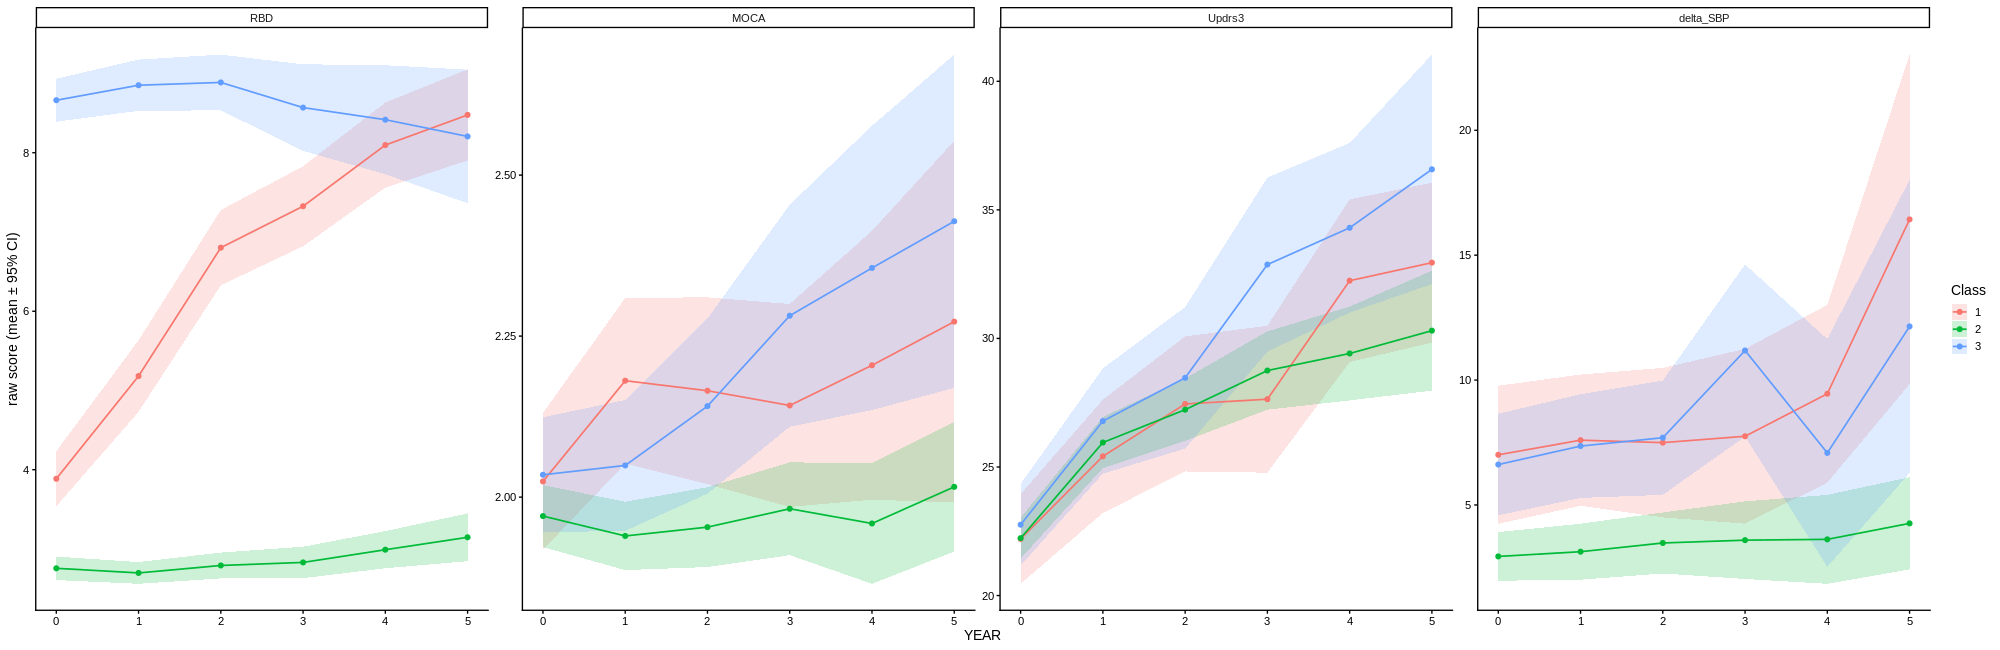

In [ ]:
%%R -w 2000 -h 650

library(ggplot2)
library(dplyr)
library(tidyr)
library(readr)

pp <- read_csv("/content/drive/MyDrive/data/random/m3_rmus_inter_slope_raw_trans_linear_postprob.csv")

pp$class <- factor(pp$class)

pp$PATNO <- as.numeric(pp$PATNO)
df$PATNO <- as.numeric(df$PATNO)

d <- df %>%
  select(PATNO, YEAR, rem, trans_moca, updrs3_score, delta_sbp) %>%
  left_join(pp %>% select(PATNO, class), by = "PATNO")

table(is.na(d$class))

long <- d %>%
  pivot_longer(
    cols = c(rem, trans_moca, updrs3_score, delta_sbp),
    names_to = "domain",
    values_to = "value"
  ) %>%
  mutate(
    domain = recode(
      domain,
      rem = "RBD",
      trans_moca = "MOCA",
      updrs3_score = "Updrs3",
      delta_sbp = "delta_SBP"
    ),
    domain = factor(domain, levels = c("RBD", "MOCA", "Updrs3", "delta_SBP"))
  )

plot_df <- long %>%
  group_by(class, YEAR, domain) %>%
  summarise(
    mean = mean(value, na.rm = TRUE),
    sd   = sd(value, na.rm = TRUE),
    n    = sum(!is.na(value)),
    se   = sd / sqrt(n),
    ci_low  = mean - 1.96 * se,
    ci_high = mean + 1.96 * se,
    .groups = "drop"
  )

ggplot(plot_df, aes(x = YEAR, y = mean, color = class, group = class, fill = class)) +
  geom_ribbon(aes(ymin = ci_low, ymax = ci_high), alpha = 0.20, colour = NA) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2) +
  facet_wrap(~domain, nrow = 1, scales = "free_y") +
  labs(
    x = "YEAR",
    y = "raw score (mean ± 95% CI)",
    color = "Class",
    fill  = "Class"
  ) + theme_classic(base_size = 14)

## OCC

In [ ]:
%%R

library(readr)
library(dplyr)
library(stringr)
library(purrr)

pp <- read_csv("/content/drive/MyDrive/data/random/m3_rmus_inter_slope_raw_trans_linear_postprob.csv")

prob_cols <- names(pp) %>% str_subset("^prob[0-9]+$")

pp <- pp %>%
  mutate(class = as.integer(class))

N <- nrow(pp)

class_metrics <- map_dfr(seq_along(prob_cols), function(k) {

  prob_k <- prob_cols[k]

  idx <- pp$class == k
  n_k <- sum(idx, na.rm = TRUE)

  pbar_k <- mean(pp[[prob_k]][idx], na.rm = TRUE)
  pi_k   <- n_k / N # hard class proportion

  occ_k <- (pbar_k / (1 - pbar_k)) / (pi_k / (1 - pi_k))

  tibble(
    class = k,
    n = n_k,
    class_prop = pi_k,
    APPA = pbar_k,
    OCC = occ_k
  )
})

class_metrics

Rows: 855 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (7): PATNO, class, prob1, prob2, prob3, Visit_Count, max_prob

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
# A tibble: 3 × 5
  class     n class_prop  APPA   OCC
  <int> <int>      <dbl> <dbl> <dbl>
1     1   114      0.133 0.776 22.6 
2     2   568      0.664 0.923  6.07
3     3   173      0.202 0.884 30.1 


# multlcmm, random=~1, zscore(moca_transform), linear

## model

In [ ]:
df_pd_final["trans_moca"] = np.sqrt(31 - df_pd_final["moca"])

In [ ]:
vars_to_z = ["rem", "trans_moca", "updrs3_score", "delta_sbp"]

base = df_pd_final[df_pd_final["YEAR"] == 0]

mu_base = base[vars_to_z].mean()
sd_base = base[vars_to_z].std()

df_pd_final[["z_bl_" + v for v in vars_to_z]] = (df_pd_final[vars_to_z] - mu_base) / sd_base

In [ ]:
df_pd_final.filter(like="z_bl_").describe()

,z_bl_rem,z_bl_trans_moca,z_bl_updrs3_score,z_bl_delta_sbp
count,3379.000000,3372.000000,2864.000000,3307.000000
mean,0.103496,0.055209,0.411544,0.057693
std,1.050013,1.141820,1.186819,1.073331
min,-1.390360,-1.688101,-2.077751,-4.249612
25%,-0.712310,-0.982341,-0.442863,-0.566941
50%,-0.034261,0.015755,0.272401,-0.018458
75%,0.982813,0.781621,1.192026,0.608380
max,3.016961,5.783589,4.666165,8.365496


In [ ]:
# activate conversion between pandas df and r df
pandas2ri.activate()

ro.globalenv["df"] = df_pd_final

In [ ]:
ro.r("""
library(lcmm)

m1_rmus_intercept_z_bl_trans_linear <- multlcmm(
  fixed   = z_bl_rem + z_bl_trans_moca + z_bl_updrs3_score + z_bl_delta_sbp ~ YEAR,
  random  = ~ 1,
  subject = "PATNO",
  ng      = 1,
  data    = df
)

summary(m1_rmus_intercept_z_bl_trans_linear)

""")

General latent class mixed model 
     fitted by maximum likelihood method 
 
multlcmm(fixed = z_bl_rem + z_bl_trans_moca + z_bl_updrs3_score + 
    z_bl_delta_sbp ~ YEAR, random = ~1, subject = "PATNO", ng = 1, 
    data = df)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 855 
     Number of observations: 12922 
     Number of latent classes: 1 
     Number of parameters: 13  
     Link functions: Linear for z_bl_rem  
                     Linear for z_bl_trans_moca  
                     Linear for z_bl_updrs3_score  
                     Linear for z_bl_delta_sbp  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  19 
     Convergence criteria: parameters= 1.5e-05 
                         : likelihood= 2.1e-05 
                         : second derivatives= 1.5e-09 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -18471.82  
     AIC: 36969.64  
     BIC: 37031.4  
 
Maximum Likelihood Estimates: 
 
Fixed effects i

In [ ]:
ro.r("""
library(lcmm)

m2_rmus_intercept_z_bl_trans_linear <- multlcmm(
  fixed   = z_bl_rem + z_bl_trans_moca + z_bl_updrs3_score + z_bl_delta_sbp ~ YEAR,
  random  = ~ 1,
  mixture  = ~ YEAR,
  subject = "PATNO",
  ng      = 2,
  data    = df,
  B = m1_rmus_intercept_z_bl_trans_linear
)

summary(m2_rmus_intercept_z_bl_trans_linear)

""")

General latent class mixed model 
     fitted by maximum likelihood method 
 
multlcmm(fixed = z_bl_rem + z_bl_trans_moca + z_bl_updrs3_score + 
    z_bl_delta_sbp ~ YEAR, mixture = ~YEAR, random = ~1, subject = "PATNO", 
    ng = 2, data = df)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 855 
     Number of observations: 12922 
     Number of latent classes: 2 
     Number of parameters: 16  
     Link functions: Linear for z_bl_rem  
                     Linear for z_bl_trans_moca  
                     Linear for z_bl_updrs3_score  
                     Linear for z_bl_delta_sbp  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  21 
     Convergence criteria: parameters= 1.6e-06 
                         : likelihood= 7.5e-08 
                         : second derivatives= 8.7e-11 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -18368.28  
     AIC: 36768.56  
     BIC: 36844.58  
 
Maximum Likelihood Estimates: 

In [ ]:
ro.r("""
library(lcmm)

m3_rmus_intercept_z_bl_trans_linear <- multlcmm(
  fixed   = z_bl_rem + z_bl_trans_moca + z_bl_updrs3_score + z_bl_delta_sbp ~ YEAR,
  random  = ~ 1,
  mixture  = ~ YEAR,
  subject = "PATNO",
  ng      = 3,
  data    = df,
  B = m1_rmus_intercept_z_bl_trans_linear
)

summary(m3_rmus_intercept_z_bl_trans_linear)

""")

General latent class mixed model 
     fitted by maximum likelihood method 
 
multlcmm(fixed = z_bl_rem + z_bl_trans_moca + z_bl_updrs3_score + 
    z_bl_delta_sbp ~ YEAR, mixture = ~YEAR, random = ~1, subject = "PATNO", 
    ng = 3, data = df)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 855 
     Number of observations: 12922 
     Number of latent classes: 3 
     Number of parameters: 19  
     Link functions: Linear for z_bl_rem  
                     Linear for z_bl_trans_moca  
                     Linear for z_bl_updrs3_score  
                     Linear for z_bl_delta_sbp  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  45 
     Convergence criteria: parameters= 6.6e-07 
                         : likelihood= 1.3e-08 
                         : second derivatives= 2e-11 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -18297.93  
     AIC: 36633.87  
     BIC: 36724.14  
 
Maximum Likelihood Estimates: 
 

In [ ]:
ro.r("""
library(lcmm)

m4_rmus_intercept_z_bl_trans_linear <- multlcmm(
  fixed   = z_bl_rem + z_bl_trans_moca + z_bl_updrs3_score + z_bl_delta_sbp ~ YEAR,
  random  = ~ 1,
  mixture  = ~ YEAR,
  subject = "PATNO",
  ng      = 4,
  data    = df,
  B = m1_rmus_intercept_z_bl_trans_linear
)

summary(m4_rmus_intercept_z_bl_trans_linear)

""")

General latent class mixed model 
     fitted by maximum likelihood method 
 
multlcmm(fixed = z_bl_rem + z_bl_trans_moca + z_bl_updrs3_score + 
    z_bl_delta_sbp ~ YEAR, mixture = ~YEAR, random = ~1, subject = "PATNO", 
    ng = 4, data = df)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 855 
     Number of observations: 12922 
     Number of latent classes: 4 
     Number of parameters: 22  
     Link functions: Linear for z_bl_rem  
                     Linear for z_bl_trans_moca  
                     Linear for z_bl_updrs3_score  
                     Linear for z_bl_delta_sbp  
 
Iteration process: 
     Maximum number of iteration reached without convergence 
     Number of iterations:  100 
     Convergence criteria: parameters= 6.8e-05 
                         : likelihood= 0.05 
                         : second derivatives= 1 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -18387.1  
     AIC: 36818.2  
     BIC: 36922.73  
 
Maximum Likelih

In [ ]:
ro.r("""
  summarytable(m1_rmus_intercept_z_bl_trans_linear, m2_rmus_intercept_z_bl_trans_linear, m3_rmus_intercept_z_bl_trans_linear, m4_rmus_intercept_z_bl_trans_linear,
               which = c("G", "loglik", "entropy", "AIC", "BIC", "%class"))
""")

                                    G    loglik   entropy      AIC      BIC
m1_rmus_intercept_z_bl_trans_linear 1 -18471.82 1.0000000 36969.64 37031.40
m2_rmus_intercept_z_bl_trans_linear 2 -18368.28 0.7946719 36768.56 36844.58
m3_rmus_intercept_z_bl_trans_linear 3 -18297.93 0.7527719 36633.87 36724.14
m4_rmus_intercept_z_bl_trans_linear 4 -18387.10 0.2705212 36818.20 36922.73
                                      %class1    %class2  %class3  %class4
m1_rmus_intercept_z_bl_trans_linear 100.00000                             
m2_rmus_intercept_z_bl_trans_linear  28.77193 71.2280702                  
m3_rmus_intercept_z_bl_trans_linear  20.23392 66.4327485 13.33333         
m4_rmus_intercept_z_bl_trans_linear  33.80117  0.3508772 34.15205 31.69591


In [ ]:
%%R

library(lcmm)

models <- list(
  m1_rmus_intercept_z_bl_trans_linear = m1_rmus_intercept_z_bl_trans_linear,
  m2_rmus_intercept_z_bl_trans_linear = m2_rmus_intercept_z_bl_trans_linear,
  m3_rmus_intercept_z_bl_trans_linear = m3_rmus_intercept_z_bl_trans_linear,
  m4_rmus_intercept_z_bl_trans_linear = m4_rmus_intercept_z_bl_trans_linear
)

for (nm in names(models)) {
  cat("\n=============================\n")
  cat("Model:", nm, "\n")
  cat("=============================\n")

  pp <- postprob(models[[nm]])

  print(pp)
}


Model: m1_rmus_intercept_z_bl_trans_linear 
Postprob function can only be used when ng > 1 
list()

Model: m2_rmus_intercept_z_bl_trans_linear 
 
Posterior classification: 
  class1 class2
N 246.00 609.00
%  28.77  71.23
 
Posterior classification table: 
     --> mean of posterior probabilities in each class 
        prob1  prob2
class1 0.8942 0.1058
class2 0.0394 0.9606
 
Posterior probaBIlities above a threshold (%): 
         class1 class2
prob>0.7  85.37  96.55
prob>0.8  77.24  93.43
prob>0.9  66.67  87.85
 
[[1]]
  class1 class2
N 246.00 609.00
%  28.77  71.23

[[2]]
        prob1  prob2
class1 0.8942 0.1058
class2 0.0394 0.9606

[[3]]
         class1 class2
prob>0.7  85.37  96.55
prob>0.8  77.24  93.43
prob>0.9  66.67  87.85


Model: m3_rmus_intercept_z_bl_trans_linear 
 
Posterior classification: 
  class1 class2 class3
N 173.00 568.00 114.00
%  20.23  66.43  13.33
 
Posterior classification table: 
     --> mean of posterior probabilities in each class 
        prob1  prob2  

In [ ]:
%%R

pp <- as.data.frame(m3_rmus_intercept_z_bl_trans_linear$pprob)

vc <- as.data.frame(table(df$PATNO))
names(vc) <- c("PATNO", "Visit_Count")
vc$PATNO <- as.numeric(as.character(vc$PATNO))

pp <- merge(pp, vc, by = "PATNO", all.x = TRUE)

prob_cols <- grep("^prob", names(pp), value = TRUE)
pp$max_prob <- apply(pp[, prob_cols, drop = FALSE], 1, max, na.rm = TRUE)

write.csv(
  pp,
  "/content/drive/MyDrive/data/random/m3_rmus_intercept_z_bl_trans_linear_postprob.csv",
  row.names = FALSE
)

In [ ]:
%%R

saveRDS(m3_rmus_intercept_z_bl_trans_linear, "/content/drive/MyDrive/data/random/m3_rmus_intercept_z_bl_trans_linear.rds")

Rows: 855 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (7): PATNO, class, prob1, prob2, prob3, Visit_Count, max_prob

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


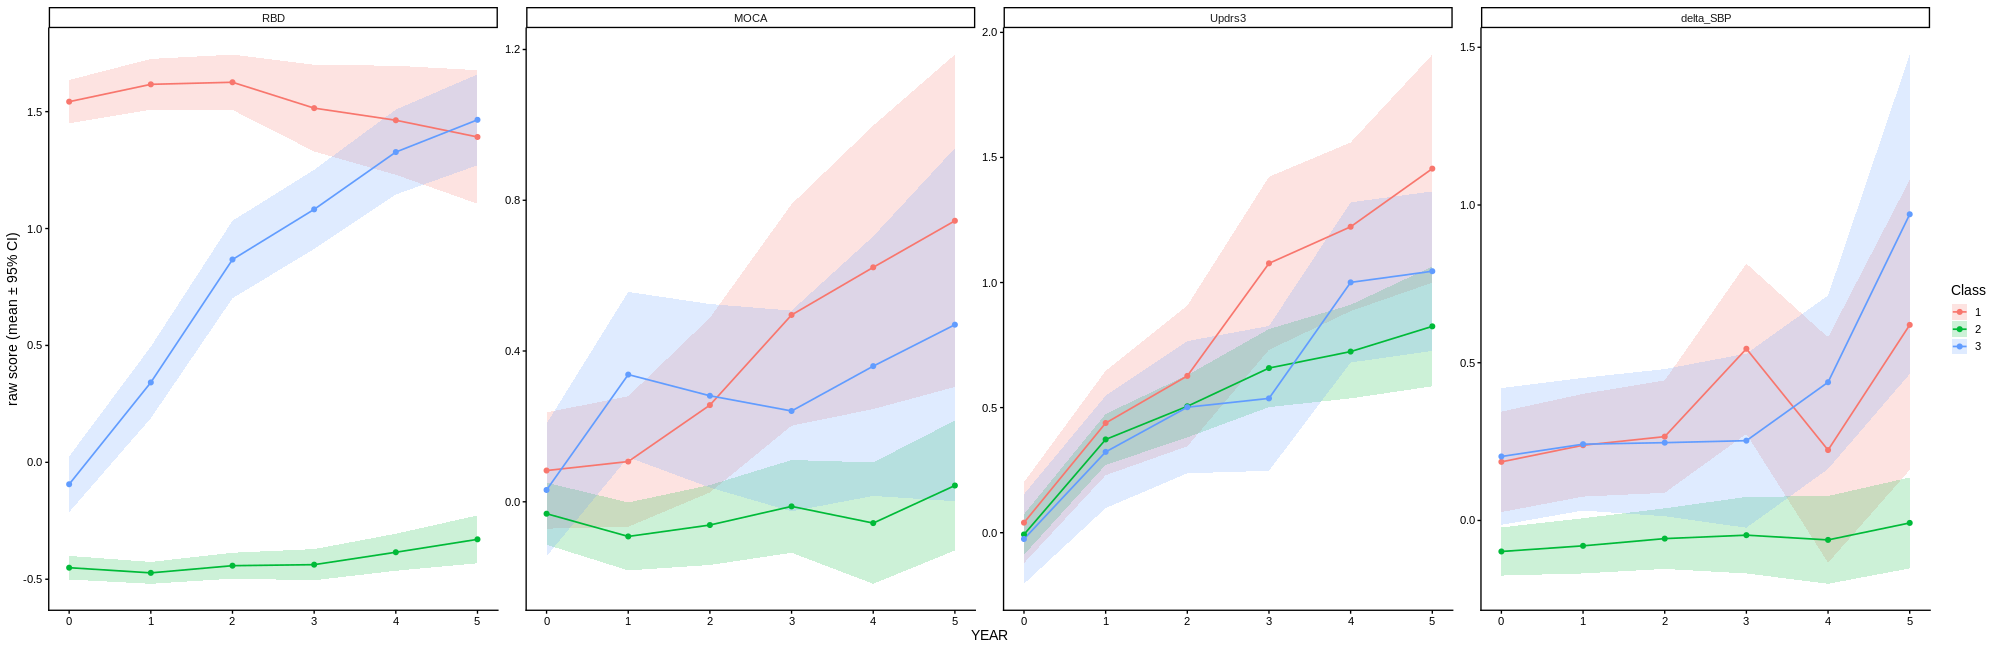

In [ ]:
%%R -w 2000 -h 650

library(ggplot2)
library(dplyr)
library(tidyr)
library(readr)

pp <- read_csv("/content/drive/MyDrive/data/random/m3_rmus_intercept_z_bl_trans_linear_postprob.csv")

pp$class <- factor(pp$class)

pp$PATNO <- as.numeric(pp$PATNO)
df$PATNO <- as.numeric(df$PATNO)

d <- df %>%
  select(PATNO, YEAR, z_bl_rem, z_bl_trans_moca, z_bl_updrs3_score, z_bl_delta_sbp) %>%
  left_join(pp %>% select(PATNO, class), by = "PATNO")

table(is.na(d$class))

long <- d %>%
  pivot_longer(
    cols = c(z_bl_rem, z_bl_trans_moca, z_bl_updrs3_score, z_bl_delta_sbp),
    names_to = "domain",
    values_to = "value"
  ) %>%
  mutate(
    domain = recode(
      domain,
      z_bl_rem = "RBD",
      z_bl_trans_moca = "MOCA",
      z_bl_updrs3_score = "Updrs3",
      z_bl_delta_sbp = "delta_SBP"
    ),
    domain = factor(domain, levels = c("RBD", "MOCA", "Updrs3", "delta_SBP"))
  )

plot_df <- long %>%
  group_by(class, YEAR, domain) %>%
  summarise(
    mean = mean(value, na.rm = TRUE),
    sd   = sd(value, na.rm = TRUE),
    n    = sum(!is.na(value)),
    se   = sd / sqrt(n),
    ci_low  = mean - 1.96 * se,
    ci_high = mean + 1.96 * se,
    .groups = "drop"
  )

ggplot(plot_df, aes(x = YEAR, y = mean, color = class, group = class, fill = class)) +
  geom_ribbon(aes(ymin = ci_low, ymax = ci_high), alpha = 0.20, colour = NA) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2) +
  facet_wrap(~domain, nrow = 1, scales = "free_y") +
  labs(
    x = "YEAR",
    y = "raw score (mean ± 95% CI)",
    color = "Class",
    fill  = "Class"
  ) + theme_classic(base_size = 14)

## OCC

In [ ]:
%%R

library(readr)
library(dplyr)
library(stringr)
library(purrr)

pp <- read_csv("/content/drive/MyDrive/data/random/m3_rmus_intercept_z_bl_trans_linear_postprob.csv")

prob_cols <- names(pp) %>% str_subset("^prob[0-9]+$")

pp <- pp %>%
  mutate(class = as.integer(class))

N <- nrow(pp)

class_metrics <- map_dfr(seq_along(prob_cols), function(k) {

  prob_k <- prob_cols[k]

  idx <- pp$class == k
  n_k <- sum(idx, na.rm = TRUE)

  pbar_k <- mean(pp[[prob_k]][idx], na.rm = TRUE)
  pi_k   <- n_k / N # hard class proportion

  occ_k <- (pbar_k / (1 - pbar_k)) / (pi_k / (1 - pi_k))

  tibble(
    class = k,
    n = n_k,
    class_prop = pi_k,
    APPA = pbar_k,
    OCC = occ_k
  )
})

class_metrics

Rows: 855 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (7): PATNO, class, prob1, prob2, prob3, Visit_Count, max_prob

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
# A tibble: 3 × 5
  class     n class_prop  APPA   OCC
  <int> <int>      <dbl> <dbl> <dbl>
1     1   173      0.202 0.868 26.0 
2     2   568      0.664 0.922  5.98
3     3   114      0.133 0.787 24.0 


# multlcmm, random=~YEAR, zscore(moca_transform), linear (3-class did not converge)

## model

In [ ]:
df_pd_final["trans_moca"] = np.sqrt(31 - df_pd_final["moca"])

In [ ]:
vars_to_z = ["rem", "trans_moca", "updrs3_score", "delta_sbp"]

base = df_pd_final[df_pd_final["YEAR"] == 0]

mu_base = base[vars_to_z].mean()
sd_base = base[vars_to_z].std()

df_pd_final[["z_bl_" + v for v in vars_to_z]] = (df_pd_final[vars_to_z] - mu_base) / sd_base

          mm_rem  mm_trans_moca  mm_updrs3_score  mm_delta_sbp
min     0.000000       0.000000         0.000000      0.000000
max   100.000000     100.000000       100.000000    100.000000
mean   33.894871      23.332204        36.911715     34.144023
std    23.824299      15.281953        17.598371      8.508297


In [ ]:
df_pd_final.filter(like="z_bl_").describe()

In [ ]:
# activate conversion between pandas df and r df
pandas2ri.activate()

ro.globalenv["df"] = df_pd_final

In [ ]:
ro.r("""
library(lcmm)

m1_rmus_inter_slope_z_bl_trans_linear <- multlcmm(
  fixed   = z_bl_rem + z_bl_trans_moca + z_bl_updrs3_score + z_bl_delta_sbp ~ YEAR,
  random  = ~ YEAR,
  subject = "PATNO",
  ng      = 1,
  data    = df
)

summary(m1_rmus_inter_slope_z_bl_trans_linear)

""")

General latent class mixed model 
     fitted by maximum likelihood method 
 
multlcmm(fixed = z_bl_rem + z_bl_trans_moca + z_bl_updrs3_score + 
    z_bl_delta_sbp ~ YEAR, random = ~YEAR, subject = "PATNO", 
    ng = 1, data = df)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 855 
     Number of observations: 12922 
     Number of latent classes: 1 
     Number of parameters: 15  
     Link functions: Linear for z_bl_rem  
                     Linear for z_bl_trans_moca  
                     Linear for z_bl_updrs3_score  
                     Linear for z_bl_delta_sbp  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  33 
     Convergence criteria: parameters= 8e-06 
                         : likelihood= 7.2e-07 
                         : second derivatives= 1.3e-09 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -18426.42  
     AIC: 36882.84  
     BIC: 36954.1  
 
Maximum Likelihood Estimates: 
 
Fixed effects 

In [ ]:
ro.r("""
library(lcmm)

m2_rmus_inter_slope_z_bl_trans_linear <- multlcmm(
  fixed   = z_bl_rem + z_bl_trans_moca + z_bl_updrs3_score + z_bl_delta_sbp ~ YEAR,
  random  = ~ YEAR,
  mixture  = ~ YEAR,
  subject = "PATNO",
  ng      = 2,
  data    = df,
  B = m1_rmus_inter_slope_z_bl_trans_linear
)

summary(m2_rmus_inter_slope_z_bl_trans_linear)

""")

General latent class mixed model 
     fitted by maximum likelihood method 
 
multlcmm(fixed = z_bl_rem + z_bl_trans_moca + z_bl_updrs3_score + 
    z_bl_delta_sbp ~ YEAR, mixture = ~YEAR, random = ~YEAR, subject = "PATNO", 
    ng = 2, data = df)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 855 
     Number of observations: 12922 
     Number of latent classes: 2 
     Number of parameters: 18  
     Link functions: Linear for z_bl_rem  
                     Linear for z_bl_trans_moca  
                     Linear for z_bl_updrs3_score  
                     Linear for z_bl_delta_sbp  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  30 
     Convergence criteria: parameters= 3.3e-05 
                         : likelihood= 5.1e-07 
                         : second derivatives= 1e-09 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -18327.4  
     AIC: 36690.8  
     BIC: 36776.32  
 
Maximum Likelihood Estimates: 


In [ ]:
ro.r("""
library(lcmm)

m3_rmus_inter_slope_z_bl_trans_linear <- multlcmm(
  fixed   = z_bl_rem + z_bl_trans_moca + z_bl_updrs3_score + z_bl_delta_sbp ~ YEAR,
  random  = ~ YEAR,
  mixture  = ~ YEAR,
  subject = "PATNO",
  ng      = 3,
  data    = df,
  B = m1_rmus_inter_slope_z_bl_trans_linear
)

summary(m3_rmus_inter_slope_z_bl_trans_linear)

""")

General latent class mixed model 
     fitted by maximum likelihood method 
 
multlcmm(fixed = z_bl_rem + z_bl_trans_moca + z_bl_updrs3_score + 
    z_bl_delta_sbp ~ YEAR, mixture = ~YEAR, random = ~YEAR, subject = "PATNO", 
    ng = 3, data = df)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 855 
     Number of observations: 12922 
     Number of latent classes: 3 
     Number of parameters: 21  
     Link functions: Linear for z_bl_rem  
                     Linear for z_bl_trans_moca  
                     Linear for z_bl_updrs3_score  
                     Linear for z_bl_delta_sbp  
 
Iteration process: 
     Maximum number of iteration reached without convergence 
     Number of iterations:  100 
     Convergence criteria: parameters= 8.1e-10 
                         : likelihood= 6e-07 
                         : second derivatives= 1 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -18295.71  
     AIC: 36633.41  
     BIC: 36733.18  
 
Maximum L

In [ ]:
ro.r("""
library(lcmm)

m4_rmus_inter_slope_z_bl_trans_linear <- multlcmm(
  fixed   = z_bl_rem + z_bl_trans_moca + z_bl_updrs3_score + z_bl_delta_sbp ~ YEAR,
  random  = ~ YEAR,
  mixture  = ~ YEAR,
  subject = "PATNO",
  ng      = 4,
  data    = df,
  B = m1_rmus_inter_slope_z_bl_trans_linear
)

summary(m4_rmus_inter_slope_z_bl_trans_linear)

""")

General latent class mixed model 
     fitted by maximum likelihood method 
 
multlcmm(fixed = z_bl_rem + z_bl_trans_moca + z_bl_updrs3_score + 
    z_bl_delta_sbp ~ YEAR, mixture = ~YEAR, random = ~YEAR, subject = "PATNO", 
    ng = 4, data = df)
 
Statistical Model: 
     Dataset: df 
     Number of subjects: 855 
     Number of observations: 12922 
     Number of latent classes: 4 
     Number of parameters: 24  
     Link functions: Linear for z_bl_rem  
                     Linear for z_bl_trans_moca  
                     Linear for z_bl_updrs3_score  
                     Linear for z_bl_delta_sbp  
 
Iteration process: 
     Maximum number of iteration reached without convergence 
     Number of iterations:  100 
     Convergence criteria: parameters= 2.2e-07 
                         : likelihood= 4.5e-05 
                         : second derivatives= 1 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -18295.8  
     AIC: 36639.6  
     BIC: 36753.63  
 
Maximum L

In [ ]:
ro.r("""
  summarytable(m1_rmus_inter_slope_z_bl_trans_linear, m2_rmus_inter_slope_z_bl_trans_linear, m3_rmus_inter_slope_z_bl_trans_linear, m4_rmus_inter_slope_z_bl_trans_linear,
               which = c("G", "loglik", "entropy", "AIC", "BIC", "%class"))
""")

                                      G    loglik   entropy      AIC      BIC
m1_rmus_inter_slope_z_bl_trans_linear 1 -18426.42 1.0000000 36882.84 36954.10
m2_rmus_inter_slope_z_bl_trans_linear 2 -18327.40 0.8465814 36690.80 36776.32
m3_rmus_inter_slope_z_bl_trans_linear 3 -18295.71 0.7561932 36633.41 36733.18
m4_rmus_inter_slope_z_bl_trans_linear 4 -18295.80 0.5414544 36639.60 36753.63
                                        %class1  %class2  %class3  %class4
m1_rmus_inter_slope_z_bl_trans_linear 100.00000                           
m2_rmus_inter_slope_z_bl_trans_linear  21.75439 78.24561                  
m3_rmus_inter_slope_z_bl_trans_linear  20.23392 66.43275 13.33333         
m4_rmus_inter_slope_z_bl_trans_linear  20.23392 65.84795  0.00000 13.91813


In [ ]:
%%R

library(lcmm)

models <- list(
  m1_rmus_inter_slope_z_bl_trans_linear = m1_rmus_inter_slope_z_bl_trans_linear,
  m2_rmus_inter_slope_z_bl_trans_linear = m2_rmus_inter_slope_z_bl_trans_linear,
  m3_rmus_inter_slope_z_bl_trans_linear = m3_rmus_inter_slope_z_bl_trans_linear,
  m4_rmus_inter_slope_z_bl_trans_linear = m4_rmus_inter_slope_z_bl_trans_linear
)

for (nm in names(models)) {
  cat("\n=============================\n")
  cat("Model:", nm, "\n")
  cat("=============================\n")

  pp <- postprob(models[[nm]])

  print(pp)
}


Model: m1_rmus_inter_slope_z_bl_trans_linear 
Postprob function can only be used when ng > 1 
list()

Model: m2_rmus_inter_slope_z_bl_trans_linear 
 
Posterior classification: 
  class1 class2
N 186.00 669.00
%  21.75  78.25
 
Posterior classification table: 
     --> mean of posterior probabilities in each class 
        prob1  prob2
class1 0.9224 0.0776
class2 0.0329 0.9671
 
Posterior probaBIlities above a threshold (%): 
         class1 class2
prob>0.7  89.25  96.71
prob>0.8  83.87  94.32
prob>0.9  77.42  89.54
 
[[1]]
  class1 class2
N 186.00 669.00
%  21.75  78.25

[[2]]
        prob1  prob2
class1 0.9224 0.0776
class2 0.0329 0.9671

[[3]]
         class1 class2
prob>0.7  89.25  96.71
prob>0.8  83.87  94.32
prob>0.9  77.42  89.54


Model: m3_rmus_inter_slope_z_bl_trans_linear 
 
Posterior classification: 
  class1 class2 class3
N 173.00 568.00 114.00
%  20.23  66.43  13.33
 
Posterior classification table: 
     --> mean of posterior probabilities in each class 
        prob1  p

In [ ]:
%%R

pp <- as.data.frame(m3_rmus_inter_slope_z_bl_trans_linear$pprob)

vc <- as.data.frame(table(df$PATNO))
names(vc) <- c("PATNO", "Visit_Count")
vc$PATNO <- as.numeric(as.character(vc$PATNO))

pp <- merge(pp, vc, by = "PATNO", all.x = TRUE)

prob_cols <- grep("^prob", names(pp), value = TRUE)
pp$max_prob <- apply(pp[, prob_cols, drop = FALSE], 1, max, na.rm = TRUE)

write.csv(
  pp,
  "/content/drive/MyDrive/data/random/m3_rmus_inter_slope_z_bl_trans_linear_postprob.csv",
  row.names = FALSE
)

In [ ]:
%%R

saveRDS(m3_rmus_inter_slope_z_bl_trans_linear, "/content/drive/MyDrive/data/random/m3_rmus_inter_slope_z_bl_trans_linear.rds")

Rows: 855 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (7): PATNO, class, prob1, prob2, prob3, Visit_Count, max_prob

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


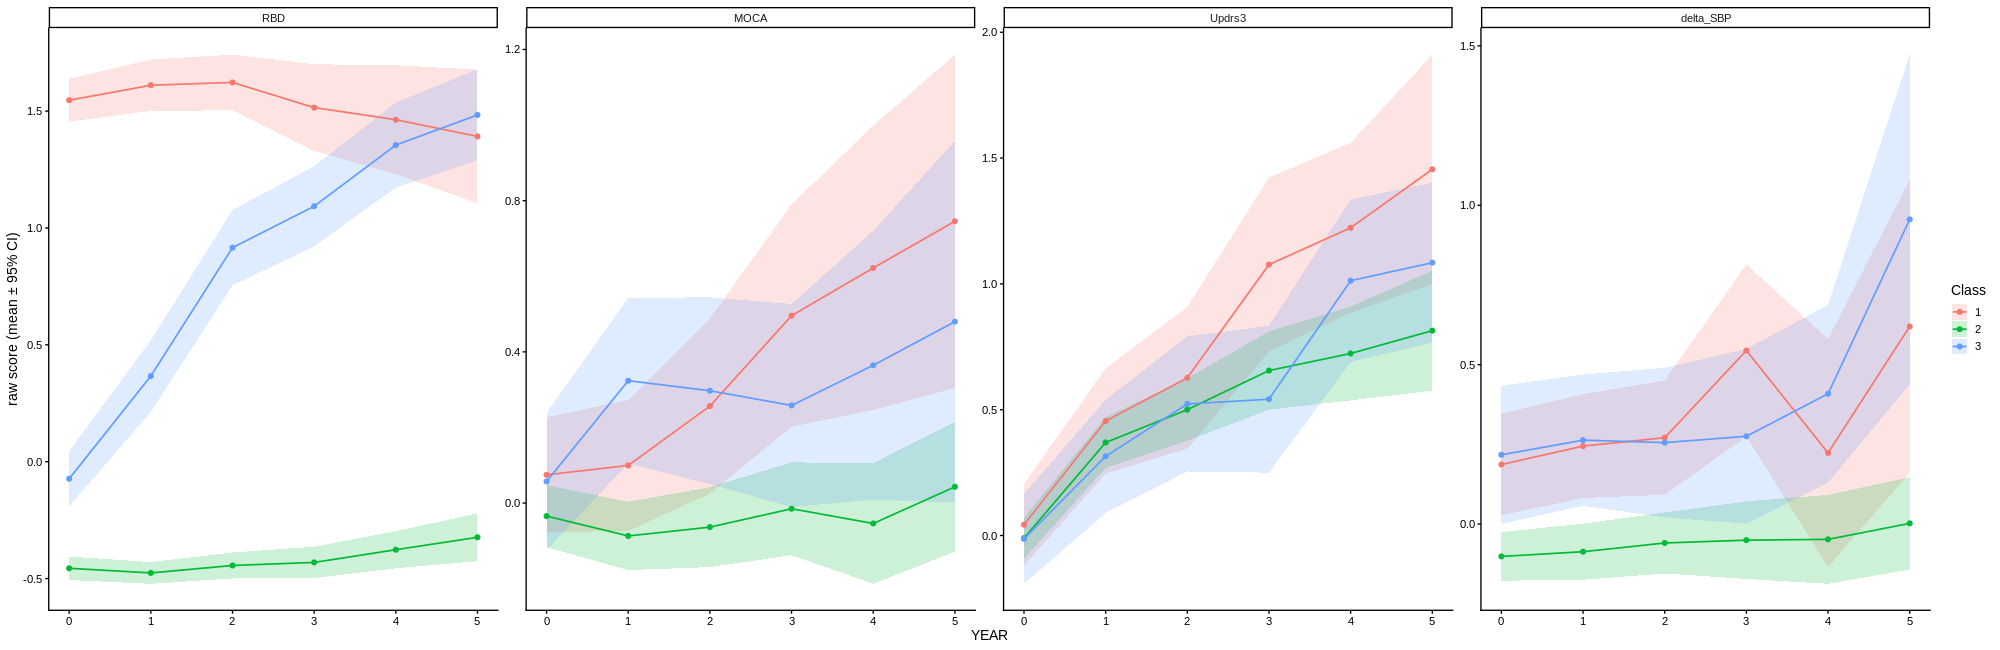

In [ ]:
%%R -w 2000 -h 650

library(ggplot2)
library(dplyr)
library(tidyr)
library(readr)

pp <- read_csv("/content/drive/MyDrive/data/random/m3_rmus_inter_slope_z_bl_trans_linear_postprob.csv")

pp$class <- factor(pp$class)

pp$PATNO <- as.numeric(pp$PATNO)
df$PATNO <- as.numeric(df$PATNO)

d <- df %>%
  select(PATNO, YEAR, z_bl_rem, z_bl_trans_moca, z_bl_updrs3_score, z_bl_delta_sbp) %>%
  left_join(pp %>% select(PATNO, class), by = "PATNO")

table(is.na(d$class))

long <- d %>%
  pivot_longer(
    cols = c(z_bl_rem, z_bl_trans_moca, z_bl_updrs3_score, z_bl_delta_sbp),
    names_to = "domain",
    values_to = "value"
  ) %>%
  mutate(
    domain = recode(
      domain,
      z_bl_rem = "RBD",
      z_bl_trans_moca = "MOCA",
      z_bl_updrs3_score = "Updrs3",
      z_bl_delta_sbp = "delta_SBP"
    ),
    domain = factor(domain, levels = c("RBD", "MOCA", "Updrs3", "delta_SBP"))
  )

plot_df <- long %>%
  group_by(class, YEAR, domain) %>%
  summarise(
    mean = mean(value, na.rm = TRUE),
    sd   = sd(value, na.rm = TRUE),
    n    = sum(!is.na(value)),
    se   = sd / sqrt(n),
    ci_low  = mean - 1.96 * se,
    ci_high = mean + 1.96 * se,
    .groups = "drop"
  )

ggplot(plot_df, aes(x = YEAR, y = mean, color = class, group = class, fill = class)) +
  geom_ribbon(aes(ymin = ci_low, ymax = ci_high), alpha = 0.20, colour = NA) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2) +
  facet_wrap(~domain, nrow = 1, scales = "free_y") +
  labs(
    x = "YEAR",
    y = "raw score (mean ± 95% CI)",
    color = "Class",
    fill  = "Class"
  ) + theme_classic(base_size = 14)

## OCC

In [ ]:
%%R

library(readr)
library(dplyr)
library(stringr)
library(purrr)

pp <- read_csv("/content/drive/MyDrive/data/random/m3_rmus_inter_slope_z_bl_trans_linear_postprob.csv")

prob_cols <- names(pp) %>% str_subset("^prob[0-9]+$")

pp <- pp %>%
  mutate(class = as.integer(class))

N <- nrow(pp)

class_metrics <- map_dfr(seq_along(prob_cols), function(k) {

  prob_k <- prob_cols[k]

  idx <- pp$class == k
  n_k <- sum(idx, na.rm = TRUE)

  pbar_k <- mean(pp[[prob_k]][idx], na.rm = TRUE)
  pi_k   <- n_k / N # hard class proportion

  occ_k <- (pbar_k / (1 - pbar_k)) / (pi_k / (1 - pi_k))

  tibble(
    class = k,
    n = n_k,
    class_prop = pi_k,
    APPA = pbar_k,
    OCC = occ_k
  )
})

class_metrics

Rows: 855 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (7): PATNO, class, prob1, prob2, prob3, Visit_Count, max_prob

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
# A tibble: 3 × 5
  class     n class_prop  APPA   OCC
  <int> <int>      <dbl> <dbl> <dbl>
1     1   173      0.202 0.884 30.1 
2     2   568      0.664 0.923  6.07
3     3   114      0.133 0.776 22.5 


# random = ~1 ARI CHI CRAMER'S V

## uni vs trans

In [ ]:
%%R

library(dplyr)
library(mclust)
library(vcd)

rem_intercept_linear <- read.csv("/content/drive/MyDrive/data/random/rem_intercept_linear_m3_postprob.csv")
rmus_intercept_raw_trans_linear <- read.csv("/content/drive/MyDrive/data/random/m3_rmus_intercept_raw_trans_linear_postprob.csv")

df_eva <- rem_intercept_linear %>%
  select(PATNO, class) %>%
  rename(classU = class) %>%
  inner_join(
    rmus_intercept_raw_trans_linear %>%
      select(PATNO, class) %>%
      rename(classM = class),
    by = "PATNO"
  )

df_eva$classU <- factor(df_eva$classU)
df_eva$classM <- factor(df_eva$classM)

# confusion matrix
tab <- table(df_eva$classU, df_eva$classM)
print(tab)

# Chi-square
chi <- chisq.test(tab)
print(chi)

# ARI
ari <- adjustedRandIndex(df_eva$classU, df_eva$classM)
print(ari)

# Cramer's V
assoc <- assocstats(tab)
print(assoc$cramer)

   
      1   2   3
  1 163   2   0
  2   1 564   3
  3   9   2 111

	Pearson's Chi-squared test

data:  tab
X-squared = 1544.7, df = 4, p-value < 2.2e-16

[1] 0.9558677
[1] 0.9504529


## uni vs zscore

In [ ]:
%%R

library(dplyr)
library(mclust)
library(vcd)

rem_intercept_linear <- read.csv("/content/drive/MyDrive/data/random/rem_intercept_linear_m3_postprob.csv")
rmus_intercept_z_bl_trans_linear <- read.csv("/content/drive/MyDrive/data/random/m3_rmus_intercept_z_bl_trans_linear_postprob.csv")

df_eva <- rem_intercept_linear %>%
  select(PATNO, class) %>%
  rename(classU = class) %>%
  inner_join(
    rmus_intercept_z_bl_trans_linear %>%
      select(PATNO, class) %>%
      rename(classM = class),
    by = "PATNO"
  )

df_eva$classU <- factor(df_eva$classU)
df_eva$classM <- factor(df_eva$classM)

# confusion matrix
tab <- table(df_eva$classU, df_eva$classM)
print(tab)

# Chi-square
chi <- chisq.test(tab)
print(chi)

# ARI
ari <- adjustedRandIndex(df_eva$classU, df_eva$classM)
print(ari)

# Cramer's V
assoc <- assocstats(tab)
print(assoc$cramer)

   
      1   2   3
  1 163   2   0
  2   1 564   3
  3   9   2 111

	Pearson's Chi-squared test

data:  tab
X-squared = 1544.7, df = 4, p-value < 2.2e-16

[1] 0.9558677
[1] 0.9504529


## trans vs zscore

In [ ]:
%%R

library(dplyr)
library(mclust)
library(vcd)

rmus_intercept_raw_trans_linear <- read.csv("/content/drive/MyDrive/data/random/m3_rmus_intercept_raw_trans_linear_postprob.csv")
rmus_intercept_z_bl_trans_linear <- read.csv("/content/drive/MyDrive/data/random/m3_rmus_intercept_z_bl_trans_linear_postprob.csv")

df_eva <- rmus_intercept_raw_trans_linear %>%
  select(PATNO, class) %>%
  rename(classU = class) %>%
  inner_join(
    rmus_intercept_z_bl_trans_linear %>%
      select(PATNO, class) %>%
      rename(classM = class),
    by = "PATNO"
  )

df_eva$classU <- factor(df_eva$classU)
df_eva$classM <- factor(df_eva$classM)

# confusion matrix
tab <- table(df_eva$classU, df_eva$classM)
print(tab)

# Chi-square
chi <- chisq.test(tab)
print(chi)

# ARI
ari <- adjustedRandIndex(df_eva$classU, df_eva$classM)
print(ari)

# Cramer's V
assoc <- assocstats(tab)
print(assoc$cramer)

   
      1   2   3
  1 173   0   0
  2   0 568   0
  3   0   0 114

	Pearson's Chi-squared test

data:  tab
X-squared = 1710, df = 4, p-value < 2.2e-16

[1] 1
[1] 1
